In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from datetime import datetime
import calendar
from math import sin, cos, sqrt, atan2, radians
from folium import FeatureGroup, LayerControl, Map, Marker
from folium.plugins import HeatMap
import matplotlib.dates as mdates
import matplotlib as mpl
from datetime import timedelta
import datetime as dt
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)
plt.style.use('fivethirtyeight')
import folium
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import pickle

In [2]:
train = pd.read_csv('./input/train.csv')
test = pd.read_csv('./input/test.csv')
test.shape

(625134, 9)

**Convert to appropriate datatype**

convert pickup datetime and dropoff datetime into date-time object

In [3]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
train['dropoff_datetime'] = pd.to_datetime(train['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


**Are there any missing values in the data?**

In [4]:
train.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

There are no missing values

**What is the time period of the dataset?**

In [5]:
print('Min pickup time:', min(train['pickup_datetime']))
print('Max pickup time:', max(train['pickup_datetime']))

Min pickup time: 2016-01-01 00:00:17
Max pickup time: 2016-06-30 23:59:39


The data has 6 months of taxi trip data, from Jan to Jun 2016

**create new day, month, hour info from Pickup time**

In [6]:
train['pickup_date'] = train['pickup_datetime'].dt.date
train['pickup_day'] = train['pickup_datetime'].apply(lambda x: x.day)
train['pickup_hour'] = train['pickup_datetime'].apply(lambda x: x.hour)
train['pickup_day_of_week'] = train['pickup_datetime'].apply(lambda x: calendar.day_name[x.weekday()])
train['dropoff_date'] = train['dropoff_datetime'].dt.date
train['dropoff_day'] = train['dropoff_datetime'].apply(lambda x: x.day)
train['dropoff_hour'] = train['dropoff_datetime'].apply(lambda x: x.hour)
train['dropoff_day_of_week'] = train['dropoff_datetime'].apply(lambda x:calendar.day_name[x.weekday()])

**Round lat lng to 3 decimal places**

In [7]:
train['pickup_latitude_round3'] = train['pickup_latitude'].apply(lambda x: round(x, 3))
train['pickup_longitude_round3'] = train['pickup_longitude'].apply(lambda x: round(x, 3))
train['dropoff_latitude_round3'] = train['dropoff_latitude'].apply(lambda x: round(x, 3))
train['dropoff_longitude_round3'] = train['dropoff_longitude'].apply(lambda x: round(x, 3))

train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_hour,pickup_day_of_week,dropoff_date,dropoff_day,dropoff_hour,dropoff_day_of_week,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,17,Monday,2016-03-14,14,17,Monday,40.768,-73.982,40.766,-73.965
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,0,Sunday,2016-06-12,12,0,Sunday,40.739,-73.980,40.731,-73.999
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,11,Tuesday,2016-01-19,19,12,Tuesday,40.764,-73.979,40.710,-74.005
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,19,Wednesday,2016-04-06,6,19,Wednesday,40.720,-74.010,40.707,-74.012
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,13,Saturday,2016-03-26,26,13,Saturday,40.793,-73.973,40.783,-73.973


**Based on Latitude and Longitude get the distance of the trip in km**

This uses Haversine Distance

In [8]:
def calculateDistance(row):
    R = 6373.0
    pickup_lat = radians(row['pickup_latitude'])
    pickup_lon = radians(row['pickup_longitude'])
    dropoff_lat = radians(row['dropoff_latitude'])
    dropoff_lon = radians(row['dropoff_longitude'])
    dlon = dropoff_lon - pickup_lon
    dlat = dropoff_lat - pickup_lat
    a = sin(dlat / 2) ** 2 + cos(pickup_lat) * cos(dropoff_lat) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

In [9]:
train['trip_distance'] = train.apply(lambda row: calculateDistance(row), axis=1)
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_day_of_week,dropoff_date,dropoff_day,dropoff_hour,dropoff_day_of_week,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3,trip_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,Monday,2016-03-14,14,17,Monday,40.768,-73.982,40.766,-73.965,1.498991
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,Sunday,2016-06-12,12,0,Sunday,40.739,-73.980,40.731,-73.999,1.806074
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,Tuesday,2016-01-19,19,12,Tuesday,40.764,-73.979,40.710,-74.005,6.387103
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,Wednesday,2016-04-06,6,19,Wednesday,40.720,-74.010,40.707,-74.012,1.485965
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,Saturday,2016-03-26,26,13,Saturday,40.793,-73.973,40.783,-73.973,1.188962


In [10]:
train['trip_duration_in_hour'] = train['trip_duration'].apply(lambda x: x/3600)
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_date,dropoff_day,dropoff_hour,dropoff_day_of_week,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3,trip_distance,trip_duration_in_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,2016-03-14,14,17,Monday,40.768,-73.982,40.766,-73.965,1.498991,0.126389
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,2016-06-12,12,0,Sunday,40.739,-73.980,40.731,-73.999,1.806074,0.184167
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,2016-01-19,19,12,Tuesday,40.764,-73.979,40.710,-74.005,6.387103,0.590000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,2016-04-06,6,19,Wednesday,40.720,-74.010,40.707,-74.012,1.485965,0.119167
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,2016-03-26,26,13,Saturday,40.793,-73.973,40.783,-73.973,1.188962,0.120833


**Exploratory Analysis**

Text(0.5, 0, 'Trip Duration (in hour)')

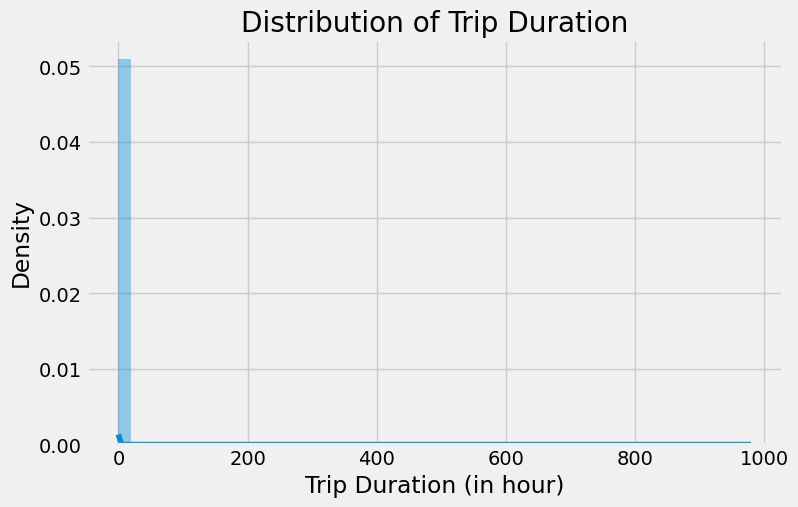

In [11]:
plt.figure(figsize=(8, 5))
sns.distplot(train['trip_duration_in_hour']).set_title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (in hour)')

There are trip duration greater than 24 hours. We will have to investigate this?

In [12]:
outlier_trip_duration = train.loc[train['trip_duration_in_hour'] > 24]
outlier_trip_duration

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_date,dropoff_day,dropoff_hour,dropoff_day_of_week,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3,trip_distance,trip_duration_in_hour
355003,id1864733,1,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,N,...,2016-01-27,27,11,Wednesday,40.644,-73.790,40.773,-73.957,20.154989,538.815556
680594,id0369307,1,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,N,...,2016-03-08,8,15,Tuesday,40.735,-73.922,40.760,-73.985,5.984365,569.327222
924150,id1325766,1,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,N,...,2016-01-31,31,1,Sunday,40.742,-73.984,40.728,-73.985,1.635641,618.781111
978383,id0053347,1,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,N,...,2016-03-25,25,18,Friday,40.649,-73.784,40.750,-73.978,19.906909,979.522778


There are 4 records which have very high trip duration, but the distance travelled is very low. These are outliers. But is there any particular location to which these trips begin or end? Trip duration is also skewed, so let us take log transformation.

We will not remove these from the analysis, beause they might be a part of test data as well

Text(0.5, 1.0, 'Distribution of trip duration (sec) in Log Scale')

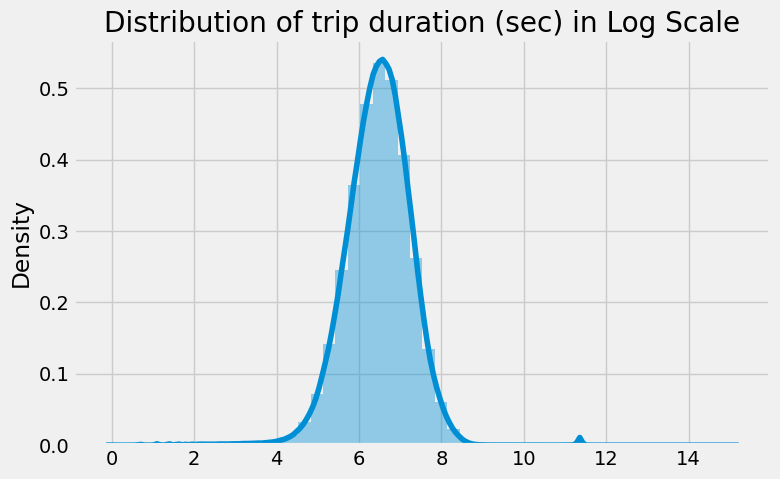

In [13]:
plt.figure(figsize=(8, 5))
sns.distplot(np.log(train['trip_duration'].values)).set_title('Distribution of Trip Duration')
plt.title('Distribution of trip duration (sec) in Log Scale')

Log transformation of the trip duration results in a normal distribution. Most trips are between 54 sec (exp(4)) and 2980 sec (exp(8)). This indicates that most trip are within one hour. But, there are trips which are less than a minute and need to be explored in detail. There are trips lasting for 100 hours which is weird as the taxi rides are within New York

**Heatmap of common locations from where pickup and dropoff occurs**

In [14]:
pickup = train.groupby(['pickup_latitude_round3', 'pickup_longitude_round3'])['id'].count().reset_index().rename(columns={'id': 'Num_Trips'})

In [15]:
pickup_map = folium.Map(location = [40.730610, -73.935242], zoom_start=10,)
print(pickup.shape)
# for index, row in pickup.iterrows():
#     folium.CircleMarker([row['pickup_latitude_round3'], row['pickup_longitude_round3']],
#                         radius = 3,
#                         fill_color='#3db7e4',
#                         fill_opacity=0.9).add_to(pickup_map)
#     count = count + 1

hm_wide = HeatMap(list(zip(pickup.pickup_latitude_round3.values, pickup.pickup_longitude_round3.values, pickup.Num_Trips.astype(float).values)),
                  min_opacity=0.2,
                  radius=5, blur=15,
                  max_zoom=1)
pickup_map.add_child(hm_wide)

pickup_map

(13024, 3)


In [16]:
pickup_map.save('pickup_map.html')

(-74.03, -73.75)

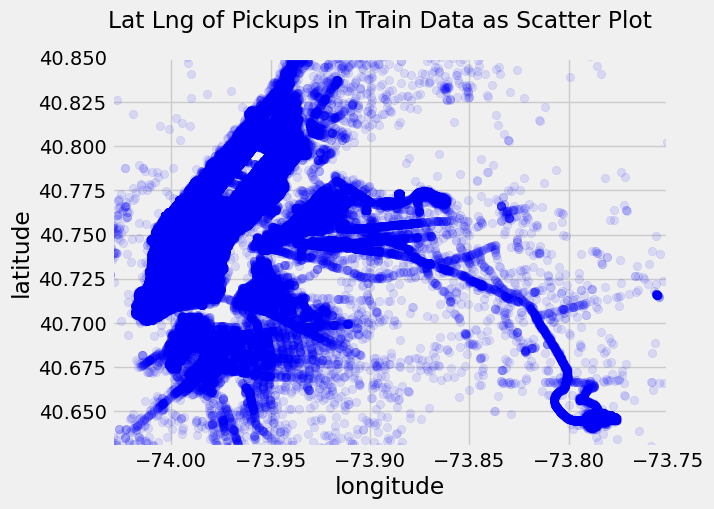

In [17]:
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)
fig, ax = plt.subplots(ncols=1, sharex=True, sharey=True)
ax.scatter(train['pickup_longitude'], train['pickup_latitude'], color='blue', label='train', alpha=0.1)

fig.suptitle('Lat Lng of Pickups in Train Data as Scatter Plot')

ax.set_ylabel('latitude')
ax.set_xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)

***This graph clearly shows heavy density of pickups near JFK***

In [18]:
drop = train.groupby(['dropoff_latitude_round3', 'dropoff_longitude_round3'])['id'].count().reset_index().rename(columns={'id': 'Num_Trips'})

In [19]:
drop_map = folium.Map(location=[40.730610, -73.935242], zoom_start=10,)
hm_wide = HeatMap(list(zip(drop.dropoff_latitude_round3.values, drop.dropoff_longitude_round3.values, drop.Num_Trips.astype(float).values)),
                  min_opacity=0.2,
                  radius=5, blur=15,
                  max_zoom=1)
drop_map.add_child(hm_wide)

drop_map.save('drop_map.html')

drop_map

Dropoff HeatMap is similar to pickup

**heatmap of trip duration, when pickup originates from a point**

In [20]:
pickup = train.groupby(['pickup_latitude_round3', 'pickup_longitude_round3'])['trip_duration'].mean().reset_index().rename(columns={'trip_duration': 'Avg_Trip_duration'})

In [21]:
pickup_map = folium.Map(location=[40.730610, -73.935242], zoom_start=10,)

hm_wide = HeatMap(list(zip(pickup.pickup_latitude_round3.values, pickup.pickup_longitude_round3.values, pickup.Avg_Trip_duration.values)),
                  min_opacity=0.2,
                  radius=7, blur=15,
                  max_zoom=1)
pickup_map.add_child(hm_wide)
pickup_map

The average trip duration, when trip originates from JFK is higher. If we zoom in, we can see that after the Manhattan, the pickups from JFK tend to have higher trip duration

**Which hours are pickup and dropoff higher?**

Text(0.5, 1.0, 'Pickup Hours Distribution')

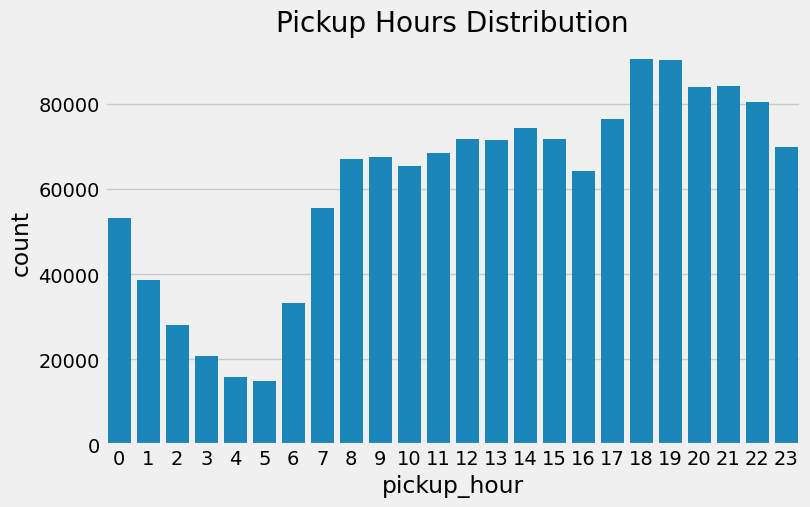

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x=train['pickup_hour']).set_title('Pickup Hours Distribution')

The pickups are much lower in the early mornings. Most pickups are around highest between 6 to 8 pm.

Text(0.5, 1.0, 'Dropoff Hours Distribution')

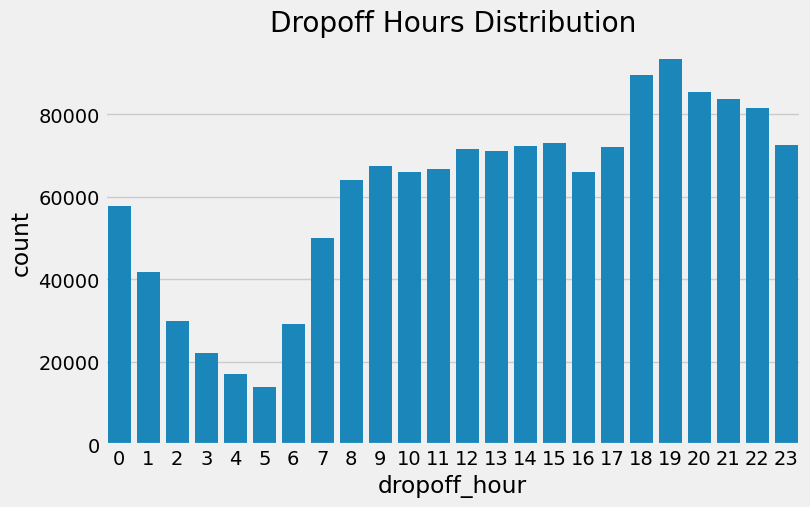

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x=train['dropoff_hour']).set_title('Dropoff Hours Distribution')

Distribution of dropoff hour very similar to pickup hour

**Pickups over the entire time period**

Text(0.5, 1.0, 'Distribution of Pickups over time')

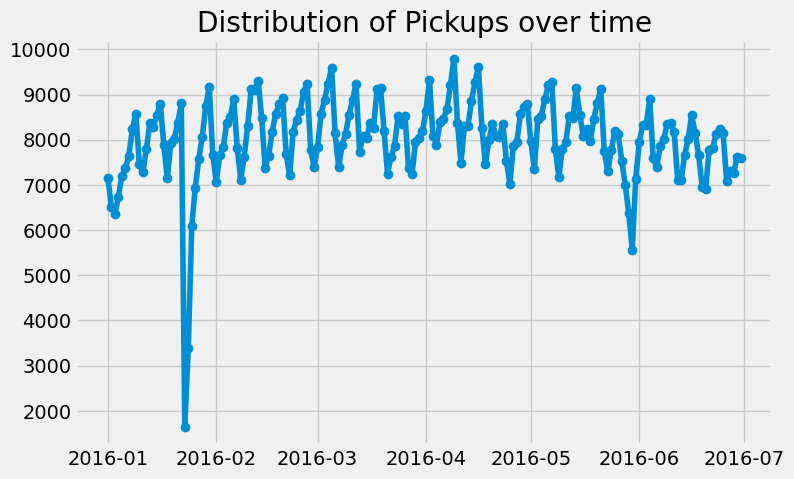

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(train.groupby('pickup_date').count()[['id']], 'o-', label='train')

plt.title('Distribution of Pickups over time')

There is a drop seen in the number of pick ups in the end the January 2016

**What is the distribution of Trip distance**

Text(0.5, 0, 'Trip Distance (log)')

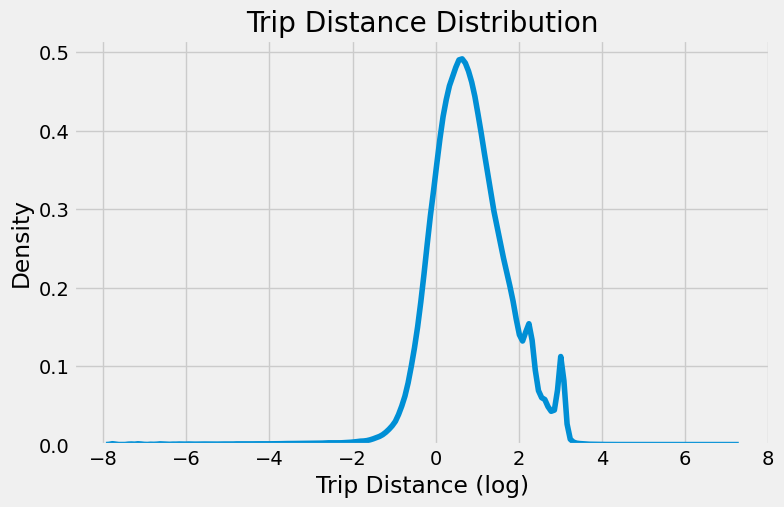

In [25]:
plt.figure(figsize=(8, 5))
sns.kdeplot(np.log(train['trip_distance'].values)).set_title('Trip Distance Distribution')
plt.xlabel('Trip Distance (log)')

**Trip Duration vs Trip Distance**

Text(0, 0.5, 'Trip Duration (log scale)')

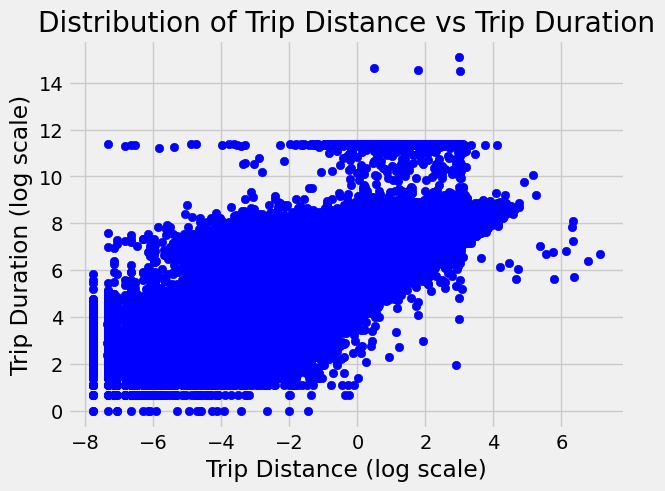

In [26]:
plt.scatter(np.log(train['trip_distance'].values), np.log(train['trip_duration'].values), color='blue', label='train')
plt.title('Distribution of Trip Distance vs Trip Duration')
plt.xlabel('Trip Distance (log scale)')
plt.ylabel('Trip Duration (log scale)')

**Is the trip duration higher at different hours?**

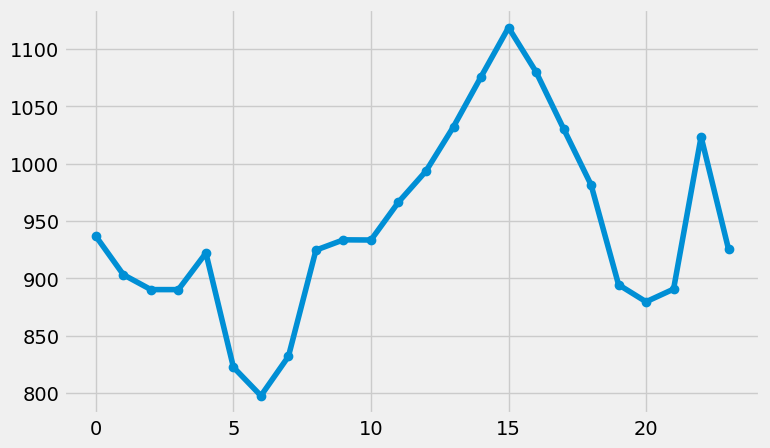

In [27]:
avg_duration_hour = train.groupby(['pickup_hour'])['trip_duration'].mean().reset_index().rename(columns={'trip_duration': 'avg_trip_duration'})
plt.figure(figsize=(8,5))
plt.plot(train.groupby(['pickup_hour'])['trip_duration'].mean(), 'o-')

Trip duration increases between 10 to 15 hours.

**Distribution of Pickups across Days**

<Axes: xlabel='count', ylabel='pickup_day_of_week'>

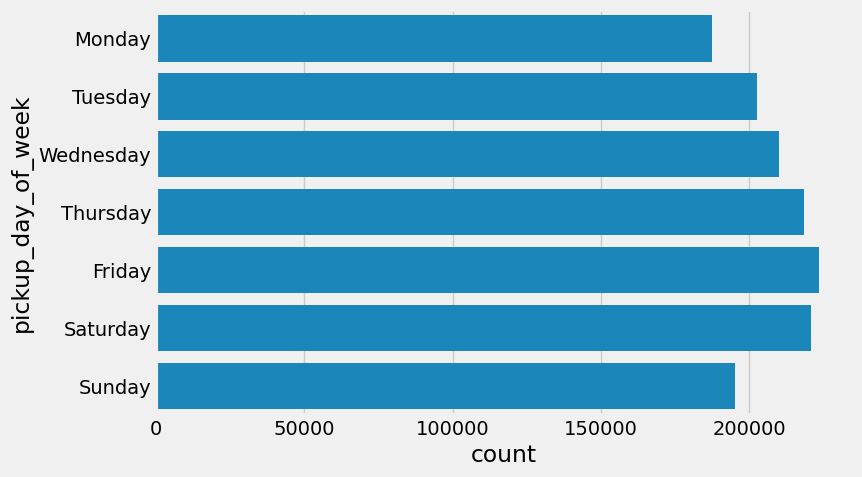

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(train['pickup_day_of_week'], order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

The number of pickups are very low on Monday. From Tuesday to Friday the number of pickups keep increasing

**Avg Trip Duration over Days of week**

In [29]:
avg_duration_day = train.groupby(['pickup_day_of_week'])['trip_duration'].mean().reset_index().rename(columns={'trip_duration': 'avg_trip_duration'})

Text(0.5, 1.0, 'Avg Trip Duration vs Pickup Days of Week')

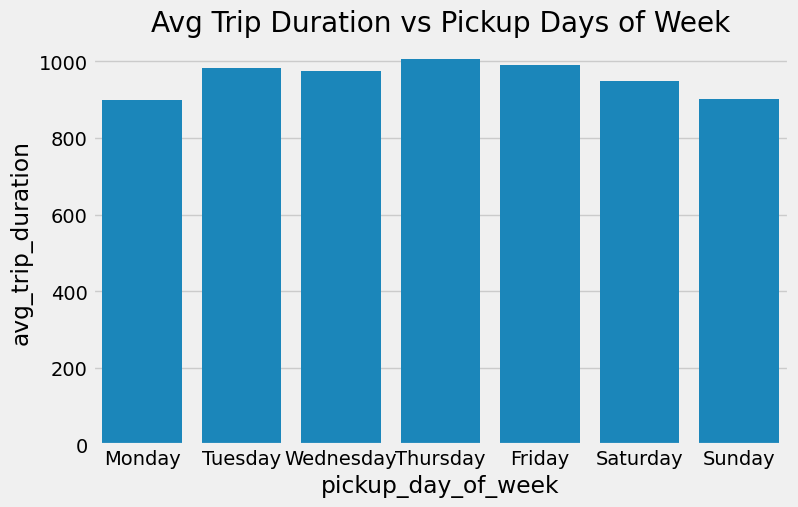

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(x='pickup_day_of_week', y='avg_trip_duration', data=avg_duration_day, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).set_title('Avg Trip Duration vs Pickup Days of Week')

The highest average speed is on Thursday

**Create a calculated field Bearing**
Bearing measures the direction of travel. The formula is: $\theta = atan2(sin \Delta\lambda \cdot cos\phi 2, cos\phi 1 \cdot sin\phi 2 - cos\phi 2 \cdot cos\delta\lambda) \lambda$ is the longitude

In [31]:
def calculateBearing(lat1, lng1, lat2, lng2):
    R = 6371
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    return np.degrees(np.arctan2(y, x))

In [32]:
train['bearing'] = train.apply(lambda row: calculateBearing(row['pickup_latitude_round3'], row['pickup_longitude_round3'], row['dropoff_latitude_round3'], row['dropoff_longitude_round3']), axis=1)

**Distribution of Bearing**

<Axes: xlabel='bearing', ylabel='Density'>

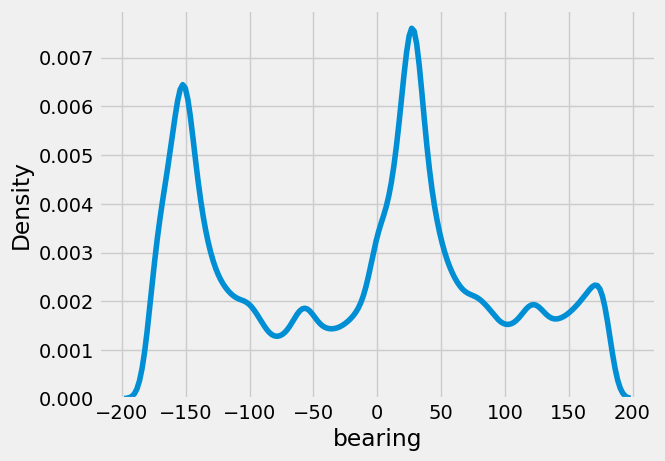

In [33]:
sns.kdeplot(train['bearing'])

**Bearing vs Trip Duration**

Text(0, 0.5, 'Trip Duration (log scale)')

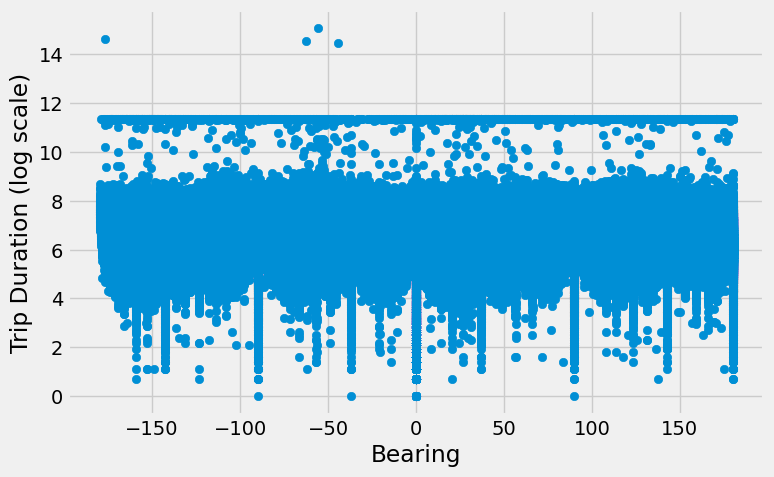

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(train['bearing'].values, y = np.log(train['trip_duration'].values))
plt.xlabel('Bearing')
plt.ylabel('Trip Duration (log scale)')

The outliers in trip duration are all around bearing -50 degrees

**Distribution of Store and FWD Flag**

In [36]:
train['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

Text(0, 0.5, 'Density')

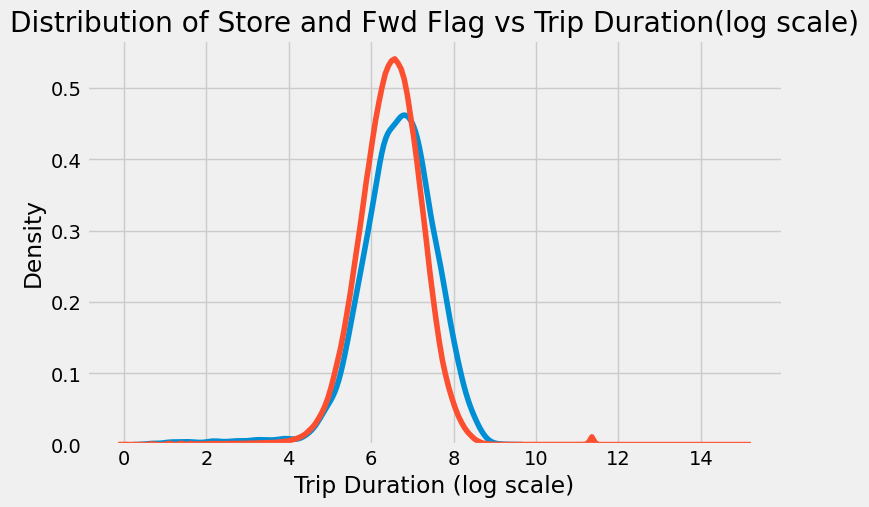

In [37]:
plt.figure(figsize=(8, 5))
sns.kdeplot(np.log(train.loc[train['store_and_fwd_flag'] == 'Y', 'trip_duration'].values), label='Store and Fwd = Yes')
sns.kdeplot(np.log(train.loc[train['store_and_fwd_flag']=='N', 'trip_duration'].values), label='Store and Fwd = No')

plt.title('Distribution of Store and Fwd Flag vs Trip Duration(log scale)')
plt.xlabel('Trip Duration (log scale)')
plt.ylabel('Density')

**Group Locations into cluster**

This will help creating neighbourhoods. And pickups from certain neighbourhoods may have a longer trip duration

In [ ]:
coords = np.vstack((train[['pickup_latitude', 'pickup_longitude']].values,
                    train[['dropoff_latitude', 'dropoff_longitude']].values,
                    test[['pickup_latitude', 'pickup_longitude']].values,
                    test[['dropoff_latitude', 'dropoff_longitude']].values))
kmeans = KMeans(n_clusters=8, random_state=0).fit(coords)
train.loc[:, 'pickup_neighbourhood'] = kmeans.predict(train[['pickup_latitude', 'pickup_longitude']])
train.loc[:, 'dropoff_neighbourhood'] = kmeans.predict(train[['dropoff_latitude', 'dropoff_longitude']])
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)
fig, ax = plt.subplots(ncols=1, sharex=True, sharey=True)
ax.scatter(train['pickup_longitude'], train['pickup_latitude'],
           c=train['pickup_neighbourhood'], label='train', alpha)